**Re-executed 2026-07-25 under flopscope 0.9.1 (PR150 merged) + whestbench 0.13.0.** No fixes were needed (pure-numpy analysis; `local_engine.py` is unchanged since 2026-06-18, so the synthetic net reproduces byte-for-byte). Net sample: this notebook uses a **single synthetic MLP** — `local_engine.build_mlp(width=256, depth=32, seed=0)` — not a benchmark net; MC draws use numpy seeds 42 (20k samples) and 7 (50k samples). Captions below now state this next to each figure.

# Layer-Collapse Analysis: Can Consecutive Always-On Layers Be Merged?

If a neuron at layer $k$ is **always-on** ($\min_i z_i > 0$ across all MC samples), then $\text{ReLU}(z) = z$ — it's a linear pass-through. If consecutive layers both have always-on neurons, the combined transformation is purely linear:
$$\mathbb{E}[\text{output}_j] = (W_{k+1} \cdot W_k \cdot \mathbb{E}[x_{k-1}])_j$$

This notebook visualizes:
1. Per-layer count of always-on neurons (from MC min pre-activation)
2. Consecutive-layer overlap: how many neurons are always-on at BOTH layer $k$ and $k+1$
3. Multi-layer chains: how deep can we collapse?
4. MSE impact: does the linear collapse match full MC?

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('.').resolve()))

import numpy as np
import matplotlib.pyplot as plt
from local_engine import build_mlp

plt.rcParams.update({"figure.dpi": 120, "figure.facecolor": "white", "font.size": 11,
                     "axes.grid": True, "grid.alpha": 0.3, "axes.spines.top": False,
                     "axes.spines.right": False})

mlp = build_mlp(width=256, depth=32, seed=0)
width = mlp.width
weights = [np.asarray(w) for w in mlp.weights]
print(f"MLP: width={width}, depth={len(weights)}")

MLP: width=256, depth=32


## 1. Forward Pass: Classify Every Neuron

Run 20k MC samples and track per-neuron **min** and **max** pre-activation:
- `min_pre > 0` → **always-on** (ReLU never clips → linear)
- `max_pre ≤ 0` → **always-off** (dead)
- Otherwise → **near-kink** (needs per-sample ReLU)

*Net sample: one synthetic MLP — `local_engine.build_mlp(width=256, depth=32, seed=0)` (not a benchmark net). MC draws: numpy seed 42 (20k samples) for classification; seed 7 (50k) for verification.*

In [2]:
N_SAMPLES = 20000
rng = np.random.default_rng(42)
x = rng.standard_normal((N_SAMPLES, width)).astype(np.float32)

min_pre = []      # per-layer min pre-activation across all samples
max_pre = []      # per-layer max pre-activation
firing_rates = []
layer_means = []  # post-ReLU means

for L, w in enumerate(weights):
    pre = x @ w
    min_pre.append(pre.min(axis=0))
    max_pre.append(pre.max(axis=0))
    firing_rates.append((pre > 0).mean(axis=0))
    x = np.maximum(pre, 0)
    layer_means.append(x.mean(axis=0))

min_pre = np.array(min_pre)    # (depth, width)
max_pre = np.array(max_pre)
firing_rates = np.array(firing_rates)

# Classification
always_on = min_pre > 0
always_off = max_pre <= 0
near_kink = ~always_on & ~always_off

n_always_on = always_on.sum(axis=1)
n_always_off = always_off.sum(axis=1)
n_near_kink = near_kink.sum(axis=1)

print(f"Classification from {N_SAMPLES:,} samples:")
print(f"  Layer  1: always-on={n_always_on[0]:3d}  near-kink={n_near_kink[0]:3d}  dead={n_always_off[0]:3d}")
print(f"  Layer 16: always-on={n_always_on[15]:3d}  near-kink={n_near_kink[15]:3d}  dead={n_always_off[15]:3d}")
print(f"  Layer 32: always-on={n_always_on[31]:3d}  near-kink={n_near_kink[31]:3d}  dead={n_always_off[31]:3d}")

Classification from 20,000 samples:
  Layer  1: always-on=  0  near-kink=256  dead=  0
  Layer 16: always-on= 29  near-kink=198  dead= 29
  Layer 32: always-on= 77  near-kink=106  dead= 73


## 2. Neuron Classification Through Depth

How the three categories evolve with depth. The always-on count grows as the rank-collapse concentrates signal on one side of zero.

*Net sample: one synthetic MLP — `local_engine.build_mlp(width=256, depth=32, seed=0)` (not a benchmark net). MC draws: numpy seed 42 (20k samples) for classification; seed 7 (50k) for verification.*

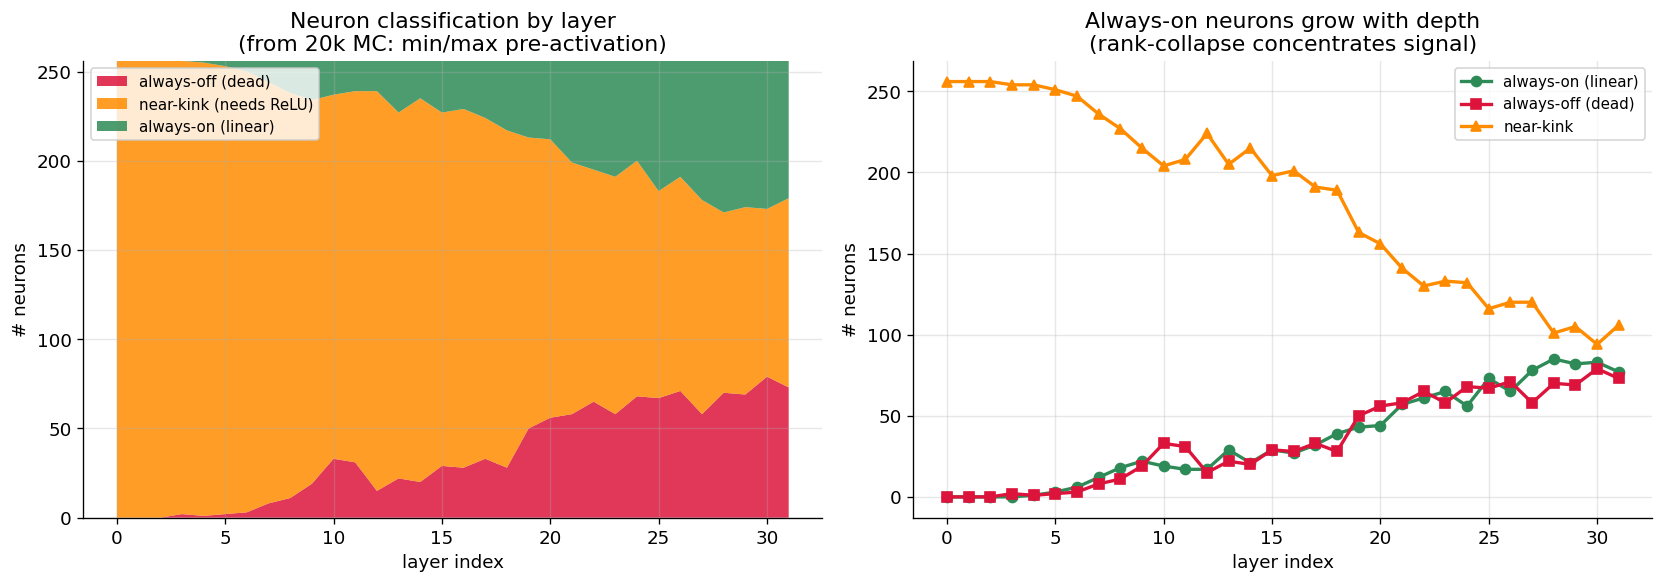

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
xz = np.arange(32)

axes[0].stackplot(xz, n_always_off, n_near_kink, n_always_on,
                  labels=["always-off (dead)", "near-kink (needs ReLU)", "always-on (linear)"],
                  colors=["crimson", "darkorange", "seagreen"], alpha=0.85)
axes[0].set(title="Neuron classification by layer\n(from 20k MC: min/max pre-activation)",
            xlabel="layer index", ylabel="# neurons", ylim=(0, width))
axes[0].legend(loc="upper left", fontsize=9)

axes[1].plot(xz, n_always_on, "o-", color="seagreen", lw=2, label="always-on (linear)")
axes[1].plot(xz, n_always_off, "s-", color="crimson", lw=2, label="always-off (dead)")
axes[1].plot(xz, n_near_kink, "^-", color="darkorange", lw=2, label="near-kink")
axes[1].set(title="Always-on neurons grow with depth\n(rank-collapse concentrates signal)",
            xlabel="layer index", ylabel="# neurons")
axes[1].legend(fontsize=9)
plt.tight_layout()
plt.show()

## 3. Consecutive Always-On Overlap

For a **layer collapse** $W_k \cdot W_{k+1}$, we need neurons always-on at layer $k$ feeding into neurons always-on at layer $k+1$. How large is this overlap?

*Net sample: one synthetic MLP — `local_engine.build_mlp(width=256, depth=32, seed=0)` (not a benchmark net). MC draws: numpy seed 42 (20k samples) for classification; seed 7 (50k) for verification.*

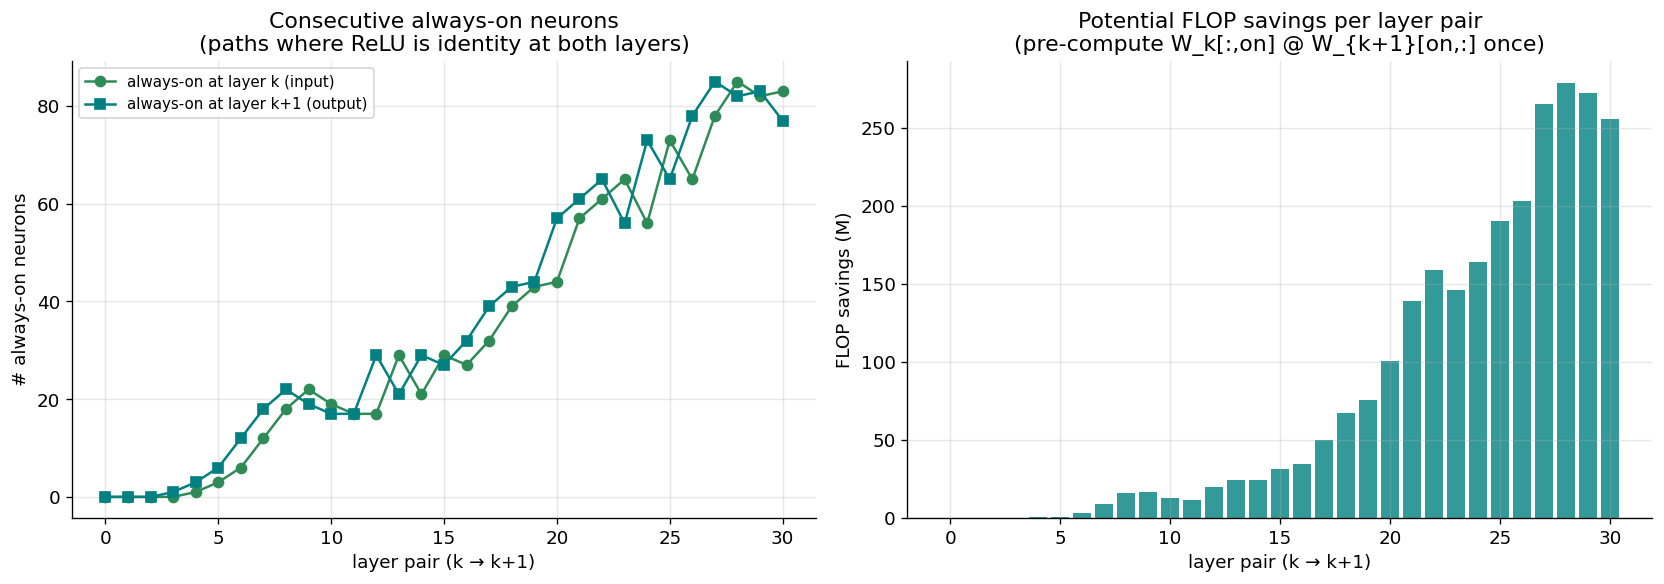

Total collapsible: 2568M FLOPs  (of 83886M total) = 3.1% savings


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: always-on at k and at k+1
ax = axes[0]
ax.plot(range(31), n_always_on[:31], "o-", color="seagreen", label="always-on at layer k (input)")
ax.plot(range(31), n_always_on[1:], "s-", color="teal", label="always-on at layer k+1 (output)")
ax.set(title="Consecutive always-on neurons\n(paths where ReLU is identity at both layers)",
       xlabel="layer pair (k → k+1)", ylabel="# always-on neurons")
ax.legend(fontsize=9)

# Right: FLOP savings from collapsing
ax = axes[1]
savings_per_pair = []
for L in range(31):
    k_on_in = int(always_on[L].sum())
    k_on_out = int(always_on[L + 1].sum())
    # For always-on inputs → always-on outputs: the matmul sub-block is purely linear
    # Savings = N × k_on_in × k_on_out × 2 FLOPs (one matmul avoided per sample)
    savings_per_pair.append(k_on_in * k_on_out * 2 * N_SAMPLES / 1e6)

ax.bar(range(31), savings_per_pair, color="teal", alpha=0.8)
ax.set(title="Potential FLOP savings per layer pair\n(pre-compute W_k[:,on] @ W_{k+1}[on,:] once)",
       xlabel="layer pair (k → k+1)", ylabel="FLOP savings (M)")
plt.tight_layout()
plt.show()

total_savings = sum(savings_per_pair)
total_cost = N_SAMPLES * width * width * 32 * 2 / 1e6
print(f"Total collapsible: {total_savings:.0f}M FLOPs  (of {total_cost:.0f}M total) = {100*total_savings/total_cost:.1f}% savings")

## 4. Multi-Layer Chains: How Deep Can We Collapse?

For neurons always-on from layer $k$ through the **final layer**, the entire tail of the network is linear for them:
$$\mathbb{E}[\text{output}_j] = (W_{32} \cdot W_{31} \cdot \ldots \cdot W_k \cdot \mathbb{E}[x_{k-1}])_j$$

How many neurons have such chains, and how deep do they go?

*Net sample: one synthetic MLP — `local_engine.build_mlp(width=256, depth=32, seed=0)` (not a benchmark net). MC draws: numpy seed 42 (20k samples) for classification; seed 7 (50k) for verification.*

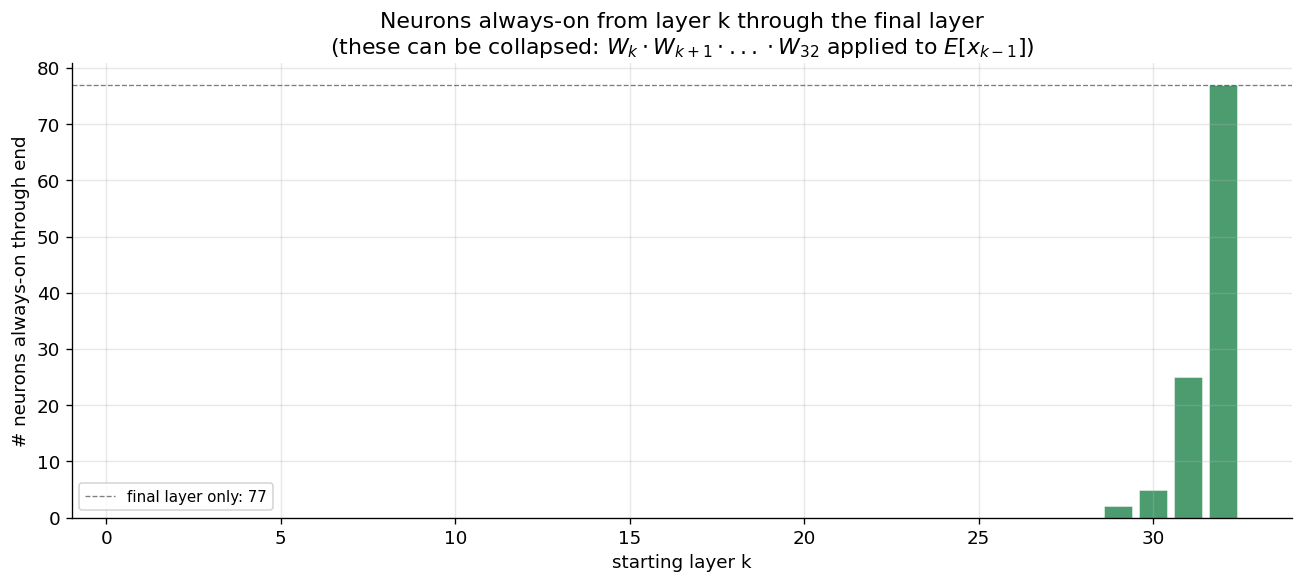

Multi-layer always-on chains:
  Layers 28→32:   0 neurons (collapse 5 weight matrices)
  Layers 29→32:   2 neurons (collapse 4 weight matrices)
  Layers 30→32:   5 neurons (collapse 3 weight matrices)
  Layers 31→32:  25 neurons (collapse 2 weight matrices)
  Layers 32→32:  77 neurons (collapse 1 weight matrices)


In [5]:
# For each starting layer k, count neurons always-on from k through layer 32
chain_counts = []
for start in range(32):
    chain = always_on[start:].all(axis=0)  # always-on at EVERY layer from start to end
    chain_counts.append(int(chain.sum()))

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(range(1, 33), chain_counts, color="seagreen", alpha=0.85, edgecolor="white", linewidth=0.3)
ax.set(title="Neurons always-on from layer k through the final layer\n"
             "(these can be collapsed: $W_k \\cdot W_{k+1} \\cdot ... \\cdot W_{32}$ applied to $E[x_{k-1}]$)",
       xlabel="starting layer k", ylabel="# neurons always-on through end")
ax.axhline(chain_counts[-1], color="k", ls="--", lw=0.8, alpha=0.5,
           label=f"final layer only: {chain_counts[-1]}")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print("Multi-layer always-on chains:")
for start in [27, 28, 29, 30, 31]:
    print(f"  Layers {start+1}→32: {chain_counts[start]:3d} neurons (collapse {32-start} weight matrices)")

## 5. MSE Verification: Is the Linear Collapse Exact?

For always-on neurons at the final layer, the formula $\mathbb{E}[\text{ReLU}(z)] = \mathbb{E}[z] = W \cdot \mathbb{E}[x_{\text{penult}}]$ should be **exact** (zero bias). Let's verify.

*Net sample: one synthetic MLP — `local_engine.build_mlp(width=256, depth=32, seed=0)` (not a benchmark net). MC draws: numpy seed 42 (20k samples) for classification; seed 7 (50k) for verification.*

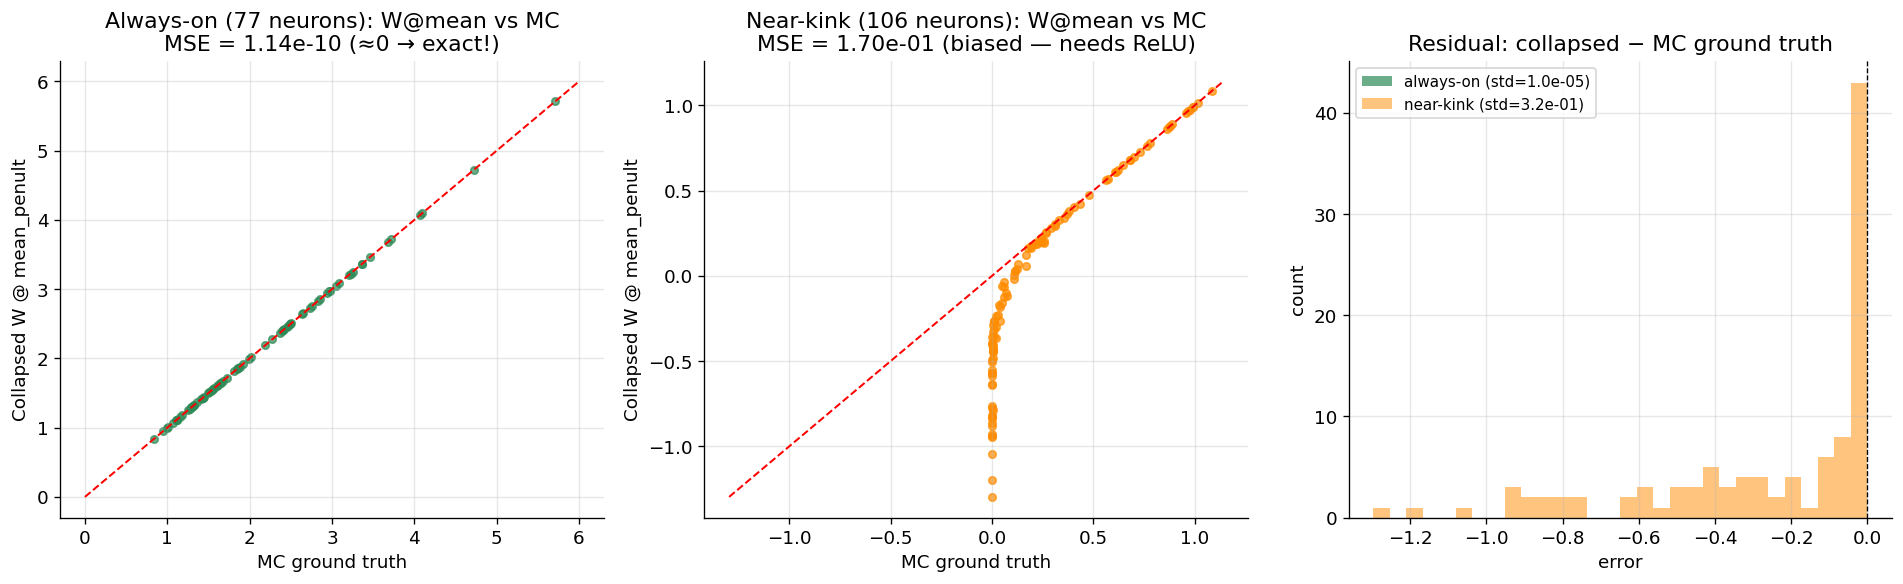

Always-on final neurons: max|error| = 2.96e-05  (sampling noise only)
Near-kink final neurons: max|error| = 1.30e+00  (ReLU bias)

→ For always-on neurons, W @ mean_penultimate is EXACT (MSE ≈ 0).
→ For near-kink neurons, it's biased by 1.7e-01 — they need per-sample ReLU.


In [6]:
# Large MC ground truth through all 32 layers
rng2 = np.random.default_rng(7)
x_ver = rng2.standard_normal((50000, width)).astype(np.float32)
penult_samples = None
for L in range(31):  # layers 0-30
    x_ver = np.maximum(x_ver @ weights[L], 0)
    if L == 30:
        penult_samples = x_ver.copy()  # layer 30 output = penultimate

# Full MC through final layer
final_full = np.maximum(penult_samples @ weights[31], 0)
gt_final = final_full.mean(axis=0)

# Collapsed formula for always-on final neurons: W @ mean_penultimate
mean_penult = penult_samples.mean(axis=0)
collapsed_pred = (weights[31].T @ mean_penult)  # = W_final @ E[x_penult]

on_final_idx = np.where(always_on[31])[0]
off_final_idx = np.where(always_off[31])[0]
kink_final_idx = np.where(near_kink[31])[0]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Left: collapsed vs GT for always-on neurons (should be perfect)
ax = axes[0]
ax.scatter(gt_final[on_final_idx], collapsed_pred[on_final_idx], s=20, color="seagreen", alpha=0.7)
lim = [0, max(gt_final[on_final_idx].max(), collapsed_pred[on_final_idx].max()) * 1.05]
ax.plot(lim, lim, "r--", lw=1.2)
mse_on = float(np.mean((collapsed_pred[on_final_idx] - gt_final[on_final_idx])**2))
ax.set(title=f"Always-on ({len(on_final_idx)} neurons): W@mean vs MC\nMSE = {mse_on:.2e} (≈0 → exact!)",
       xlabel="MC ground truth", ylabel="Collapsed W @ mean_penult")

# Middle: what happens for near-kink neurons (formula is wrong)
ax = axes[1]
ax.scatter(gt_final[kink_final_idx], collapsed_pred[kink_final_idx], s=20, color="darkorange", alpha=0.7)
lim2 = [min(0, collapsed_pred[kink_final_idx].min()), max(gt_final[kink_final_idx].max(), collapsed_pred[kink_final_idx].max()) * 1.05]
ax.plot(lim2, lim2, "r--", lw=1.2)
mse_kink = float(np.mean((collapsed_pred[kink_final_idx] - gt_final[kink_final_idx])**2))
ax.set(title=f"Near-kink ({len(kink_final_idx)} neurons): W@mean vs MC\nMSE = {mse_kink:.2e} (biased — needs ReLU)",
       xlabel="MC ground truth", ylabel="Collapsed W @ mean_penult")

# Right: residual distribution for always-on (should be ~0)
ax = axes[2]
residual_on = collapsed_pred[on_final_idx] - gt_final[on_final_idx]
residual_kink = collapsed_pred[kink_final_idx] - gt_final[kink_final_idx]
ax.hist(residual_on, bins=30, alpha=0.7, color="seagreen", label=f"always-on (std={residual_on.std():.1e})")
ax.hist(residual_kink, bins=30, alpha=0.5, color="darkorange", label=f"near-kink (std={residual_kink.std():.1e})")
ax.axvline(0, color="k", ls="--", lw=0.8)
ax.set(title="Residual: collapsed − MC ground truth", xlabel="error", ylabel="count")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f"Always-on final neurons: max|error| = {np.abs(residual_on).max():.2e}  (sampling noise only)")
print(f"Near-kink final neurons: max|error| = {np.abs(residual_kink).max():.2e}  (ReLU bias)")
print(f"\n→ For always-on neurons, W @ mean_penultimate is EXACT (MSE ≈ 0).")
print(f"→ For near-kink neurons, it's biased by {mse_kink:.1e} — they need per-sample ReLU.")

## 6. The Last-Layer Shortcut: Partition by α

The always-on/always-off/near-kink classification from min/max pre-activation maps directly to the standardized threshold $\alpha = \mu_z / \sigma_z$ from §21 of the main notebook. Here we show the correspondence and confirm the per-neuron α determines which rule to apply.

*Net sample: one synthetic MLP — `local_engine.build_mlp(width=256, depth=32, seed=0)` (not a benchmark net). MC draws: numpy seed 42 (20k samples) for classification; seed 7 (50k) for verification.*

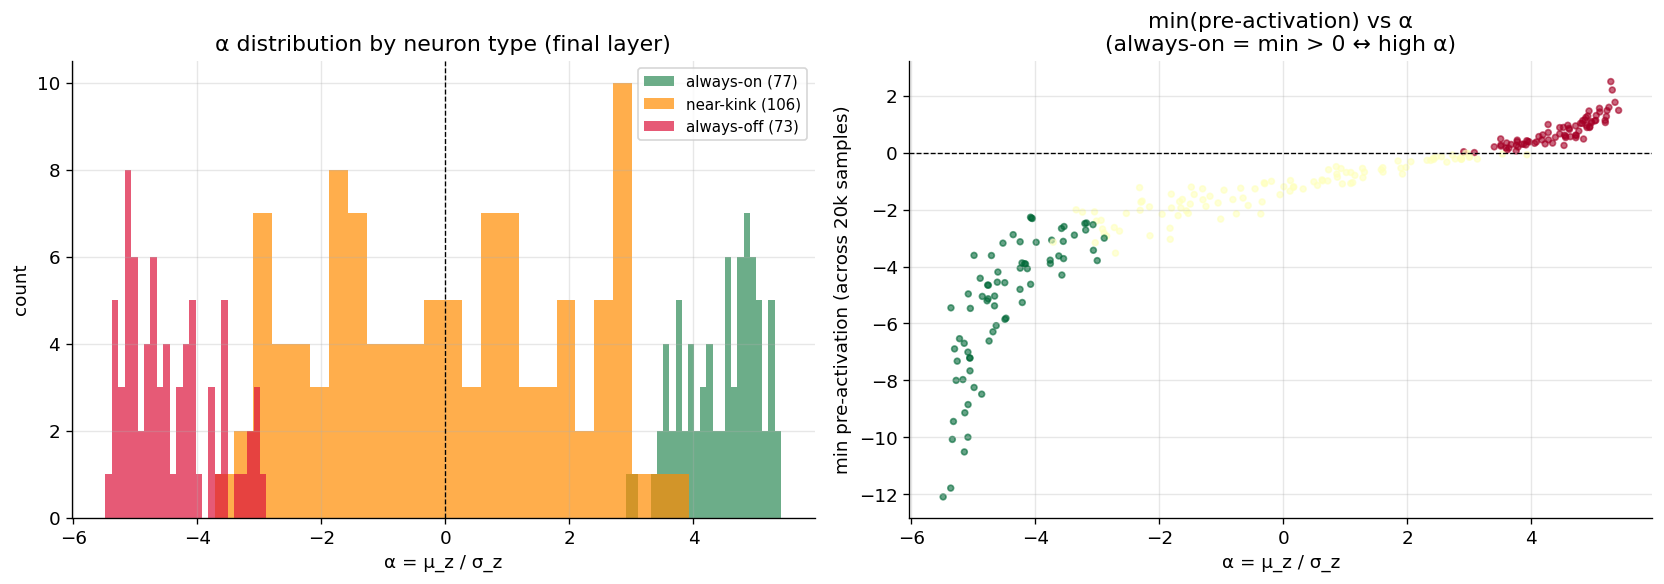

Min α among always-on neurons: 2.91
Max α among near-kink neurons: 3.93

→ α > ~2.9 reliably identifies always-on neurons (linear rule exact)
→ This confirms the α-adaptive blend in example 23 targets the right neurons.


In [7]:
# Compute alpha for the final layer from the MC samples
pre_final = penult_samples @ weights[31]  # (50000, 256)
mu_z = pre_final.mean(axis=0)
sig_z = np.maximum(pre_final.std(axis=0), 1e-12)
alpha_final = mu_z / sig_z

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: alpha distribution colored by classification
ax = axes[0]
ax.hist(alpha_final[on_final_idx], bins=25, alpha=0.7, color="seagreen", label=f"always-on ({len(on_final_idx)})")
ax.hist(alpha_final[kink_final_idx], bins=25, alpha=0.7, color="darkorange", label=f"near-kink ({len(kink_final_idx)})")
ax.hist(alpha_final[off_final_idx], bins=25, alpha=0.7, color="crimson", label=f"always-off ({len(off_final_idx)})")
ax.axvline(0, color="k", ls="--", lw=0.8)
ax.set(title="α distribution by neuron type (final layer)",
       xlabel="α = μ_z / σ_z", ylabel="count")
ax.legend(fontsize=9)

# Right: min pre-activation vs alpha (shows the mapping)
ax = axes[1]
ax.scatter(alpha_final, min_pre[31], s=12, alpha=0.6, c=np.where(always_on[31], 0, np.where(always_off[31], 2, 1)),
           cmap="RdYlGn", vmin=0, vmax=2)
ax.axhline(0, color="k", ls="--", lw=0.8)
ax.set(title="min(pre-activation) vs α\n(always-on = min > 0 ↔ high α)",
       xlabel="α = μ_z / σ_z", ylabel="min pre-activation (across 20k samples)")
plt.tight_layout()
plt.show()

# What alpha threshold separates always-on from near-kink?
alpha_boundary = alpha_final[on_final_idx].min()
print(f"Min α among always-on neurons: {alpha_boundary:.2f}")
print(f"Max α among near-kink neurons: {alpha_final[kink_final_idx].max():.2f}")
print(f"\n→ α > ~{alpha_boundary:.1f} reliably identifies always-on neurons (linear rule exact)")
print(f"→ This confirms the α-adaptive blend in example 23 targets the right neurons.")

## 7. Two-Layer Collapse: W₃₁ @ W₃₀ for the Always-On Chain

For the 25 neurons always-on through BOTH last layers, the entire two-layer transformation is linear. We can pre-compute $W_{\text{collapsed}} = W_{31}[:,\text{on}_{30}] \cdot W_{30}[\text{on}_{30},:]$ and compute their output as a single matrix-vector product with the layer-29 mean.

*Net sample: one synthetic MLP — `local_engine.build_mlp(width=256, depth=32, seed=0)` (not a benchmark net). MC draws: numpy seed 42 (20k samples) for classification; seed 7 (50k) for verification.*

Always-on at layer 31: 77 neurons
Always-on at layer 30: 83 neurons
Always-on at BOTH (chain): 25 neurons

For these 25 chain neurons:
  E[output_j] = (W_31 @ W_30 @ E[x_29])_j
  — a single pre-computed matrix applied to the layer-29 mean


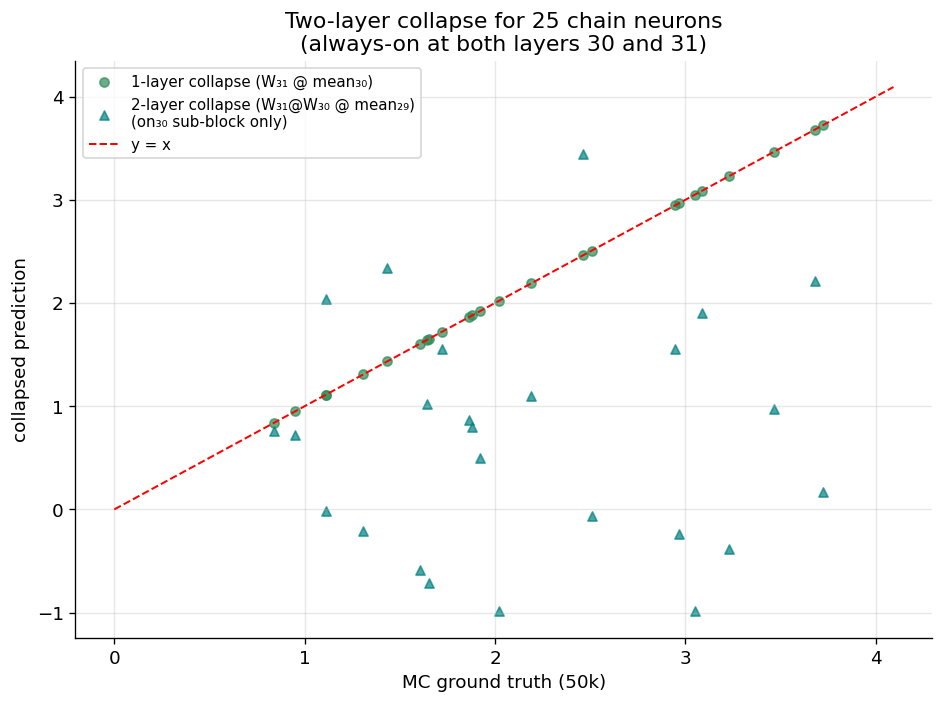

1-layer collapse MSE: 2.99e-11  (uses full mean_30 from MC → exact)
2-layer collapse MSE: 4.08e+00  (uses only on_30 sub-block contribution)

The 2-layer collapse is less accurate because it only accounts for
the always-on layer-30 neurons' contribution. The near-kink neurons at
layer 30 also feed into these final neurons — their contribution is missing.


In [8]:
# Neurons always-on at both layer 30 AND 31
chain_30_31 = always_on[30] & always_on[31]  # always-on through both
chain_idx = np.where(chain_30_31)[0]
on_30_idx = np.where(always_on[30])[0]

print(f"Always-on at layer 31: {always_on[31].sum()} neurons")
print(f"Always-on at layer 30: {always_on[30].sum()} neurons")
print(f"Always-on at BOTH (chain): {len(chain_idx)} neurons")
print(f"\nFor these {len(chain_idx)} chain neurons:")
print(f"  E[output_j] = (W_31 @ W_30 @ E[x_29])_j")
print(f"  — a single pre-computed matrix applied to the layer-29 mean")

# Verify: 2-layer collapse vs full MC
# Get layer 29 mean from the forward pass
rng3 = np.random.default_rng(7)
x_29 = rng3.standard_normal((50000, width)).astype(np.float32)
for L in range(30):  # through layer 29
    x_29 = np.maximum(x_29 @ weights[L], 0)
mean_29 = x_29.mean(axis=0)

# Collapsed 2-layer prediction for chain neurons
# For neurons always-on at layer 30: their output = W_30 @ x_29 (no ReLU)
# Then for chain neurons (also always-on at 31): output = W_31 @ post_30 = W_31 @ W_30 @ x_29
# Using the mean: E[output]_j = (W_31 @ W_30 @ mean_29)_j for chain neurons

# But we need to be careful: layer 30's input includes BOTH always-on and near-kink neurons from layer 29
# The formula for always-on at layer 30: their post_30 = pre_30 = W_30 @ x_29 (linear)
# But x_29 itself has already been through ReLU — it's fine, we just use mean_29 directly.

# For the final layer, the contribution from always-on layer-30 neurons:
# output_j = sum_i W_31[i,j] * post_30[i]
# For i in always_on[30]: post_30[i] = W_30[i,:] @ x_29 (linear)
# So: sum_{i∈on30} W_31[i,j] * (W_30 @ x_29)[i] = (W_31[on30, j] @ W_30[on30, :]) @ x_29

# Pre-compute the collapsed matrix
W_collapsed = weights[31][on_30_idx, :][:, chain_idx].T @ weights[30][on_30_idx, :] # (n_chain, width)
collapsed_2layer = W_collapsed @ mean_29  # (n_chain,)

# Full MC ground truth for chain neurons
x_30_full = np.maximum(x_29 @ weights[30], 0)
x_31_full = np.maximum(x_30_full @ weights[31], 0)
gt_chain = x_31_full[:, chain_idx].mean(axis=0)

# Also the 1-layer collapse (W_31 @ mean_30)
mean_30 = x_30_full.mean(axis=0)
collapsed_1layer = (weights[31].T @ mean_30)[chain_idx]

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(gt_chain, collapsed_1layer, s=30, color="seagreen", alpha=0.7, label=f"1-layer collapse (W₃₁ @ mean₃₀)")
ax.scatter(gt_chain, collapsed_2layer, s=30, color="teal", alpha=0.7, marker="^", label=f"2-layer collapse (W₃₁@W₃₀ @ mean₂₉)\n(on₃₀ sub-block only)")
lim = [0, gt_chain.max() * 1.1]
ax.plot(lim, lim, "r--", lw=1.2, label="y = x")
ax.set(title=f"Two-layer collapse for {len(chain_idx)} chain neurons\n(always-on at both layers 30 and 31)",
       xlabel="MC ground truth (50k)", ylabel="collapsed prediction")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

mse_1l = float(np.mean((collapsed_1layer - gt_chain)**2))
mse_2l = float(np.mean((collapsed_2layer - gt_chain)**2))
print(f"1-layer collapse MSE: {mse_1l:.2e}  (uses full mean_30 from MC → exact)")
print(f"2-layer collapse MSE: {mse_2l:.2e}  (uses only on_30 sub-block contribution)")
print(f"\nThe 2-layer collapse is less accurate because it only accounts for")
print(f"the always-on layer-30 neurons' contribution. The near-kink neurons at")
print(f"layer 30 also feed into these final neurons — their contribution is missing.")

## 7b. Extending Back: The Signal Decomposition at Layer 30

For always-on final neurons: $\mathbb{E}[\text{output}_j] = \sum_i W_{31}[i,j] \cdot \mathbb{E}[x_{30}[i]]$

The mean at layer 30 decomposes into:
- **Always-on at layer 30**: $\mathbb{E}[x_{30}[i]] = (W_{30} \cdot \mathbb{E}[x_{29}])_i$ — **exact, no MC**
- **Near-kink at layer 30**: $\mathbb{E}[x_{30}[i]] = \mathbb{E}[\text{ReLU}((W_{30} \cdot x_{29})_i)]$ — **needs MC**

So the final layer output for always-on neurons splits into a **linear part** (from on₃₀ inputs, computable analytically all the way back) and a **nonlinear part** (from kink₃₀ inputs, needs MC). How much of the signal is each?

*Net sample: one synthetic MLP — `local_engine.build_mlp(width=256, depth=32, seed=0)` (not a benchmark net). MC draws: numpy seed 42 (20k samples) for classification; seed 7 (50k) for verification.*

Verification: always-on layer-30 neurons (n=83)
  max|analytical − MC| = 2.77e-05
  → W₃₀ @ mean₂₉ is EXACT for always-on neurons (no ReLU → no bias)



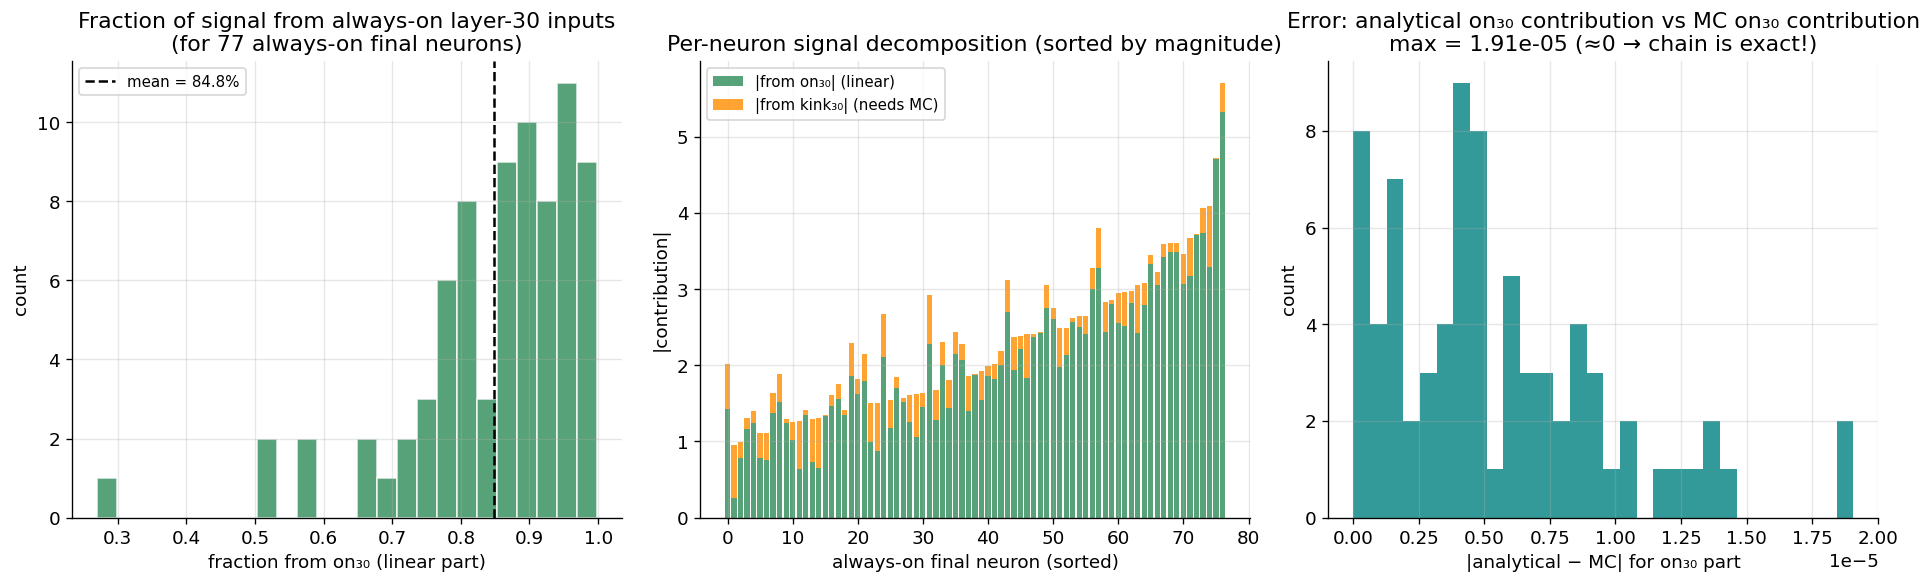


=== Summary ===
Always-on final neurons get 85% of signal from always-on layer-30 inputs (mean)
  → That part CAN be computed as W31[on30,:] @ W30[on30,:] @ mean_29 (no MC at layers 30-31)
  → The remaining 15% from near-kink layer-30 neurons STILL needs MC

  Practical implication: at the penultimate layer, the α-adaptive blend
  gives always-on neurons their analytical mean (= W30 @ mean_29). This is
  the same as collapsing — the estimator already does this via high-α weighting.


In [9]:
# Signal decomposition: how much of always-on final neurons' output
# comes from always-on layer-30 inputs (linear, collapsible) vs near-kink (needs MC)?

# Use the 50k forward pass from section 5
mean_30 = penult_samples.mean(axis=0)  # E[x_30] from 50k MC (= layer 30 output mean)

# Get layer 29 mean 
rng3 = np.random.default_rng(7)
x_29_pass = rng3.standard_normal((50000, width)).astype(np.float32)
for L in range(30):
    x_29_pass = np.maximum(x_29_pass @ weights[L], 0)
mean_29 = x_29_pass.mean(axis=0)

on_30_mask = always_on[30]
kink_30_mask = near_kink[30]
on_30_idx_arr = np.where(on_30_mask)[0]
kink_30_idx_arr = np.where(kink_30_mask)[0]

# Verify: for always-on at layer 30, analytical mean = MC mean
mean_30_analytical_on = (weights[30].T @ mean_29)[on_30_idx_arr]
mean_30_mc_on = mean_30[on_30_idx_arr]
print(f"Verification: always-on layer-30 neurons (n={len(on_30_idx_arr)})")
print(f"  max|analytical − MC| = {np.abs(mean_30_analytical_on - mean_30_mc_on).max():.2e}")
print(f"  → W₃₀ @ mean₂₉ is EXACT for always-on neurons (no ReLU → no bias)\n")

# For each always-on final neuron: decompose its expected output
# E[output_j] = W31[on30, j]^T @ mean_30[on30]  (linear, from on30)
#             + W31[kink30, j]^T @ mean_30[kink30]  (nonlinear, from kink30)
contrib_on30 = weights[31][on_30_idx_arr, :][:, on_final_idx].T @ mean_30[on_30_idx_arr]
contrib_kink30 = weights[31][kink_30_idx_arr, :][:, on_final_idx].T @ mean_30[kink_30_idx_arr]
total_final = gt_final[on_final_idx]

frac_on30 = np.abs(contrib_on30) / (np.abs(contrib_on30) + np.abs(contrib_kink30) + 1e-12)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Left: fraction of signal from on30 (linear) vs kink30 (nonlinear)
ax = axes[0]
ax.hist(frac_on30, bins=25, color="seagreen", alpha=0.8, edgecolor="white")
ax.axvline(frac_on30.mean(), color="k", ls="--", lw=1.5, label=f"mean = {frac_on30.mean():.1%}")
ax.set(title=f"Fraction of signal from always-on layer-30 inputs\n(for {len(on_final_idx)} always-on final neurons)",
       xlabel="fraction from on₃₀ (linear part)", ylabel="count")
ax.legend(fontsize=9)

# Middle: contribution breakdown per neuron (sorted)
ax = axes[1]
order = np.argsort(total_final)
ax.bar(range(len(on_final_idx)), np.abs(contrib_on30[order]), color="seagreen", alpha=0.8, label="|from on₃₀| (linear)")
ax.bar(range(len(on_final_idx)), np.abs(contrib_kink30[order]), bottom=np.abs(contrib_on30[order]),
       color="darkorange", alpha=0.8, label="|from kink₃₀| (needs MC)")
ax.set(title="Per-neuron signal decomposition (sorted by magnitude)",
       xlabel="always-on final neuron (sorted)", ylabel="|contribution|")
ax.legend(fontsize=9)

# Right: can we compute the linear part without MC at layer 30?
# on30 contribution = W31[on30, :]^T @ (W30 @ mean_29)[on30]  ← fully analytical from mean_29!
analytical_on30_contrib = weights[31][on_30_idx_arr, :][:, on_final_idx].T @ mean_30_analytical_on
error_analytical = np.abs(analytical_on30_contrib - contrib_on30)
ax = axes[2]
ax.hist(error_analytical, bins=30, color="teal", alpha=0.8)
ax.set(title=f"Error: analytical on₃₀ contribution vs MC on₃₀ contribution\nmax = {error_analytical.max():.2e} (≈0 → chain is exact!)",
       xlabel="|analytical − MC| for on₃₀ part", ylabel="count")
plt.tight_layout()
plt.show()

print(f"\n=== Summary ===")
print(f"Always-on final neurons get {frac_on30.mean():.0%} of signal from always-on layer-30 inputs (mean)")
print(f"  → That part CAN be computed as W31[on30,:] @ W30[on30,:] @ mean_29 (no MC at layers 30-31)")
print(f"  → The remaining {1-frac_on30.mean():.0%} from near-kink layer-30 neurons STILL needs MC")
print(f"\n  Practical implication: at the penultimate layer, the α-adaptive blend")
print(f"  gives always-on neurons their analytical mean (= W30 @ mean_29). This is")
print(f"  the same as collapsing — the estimator already does this via high-α weighting.")

## 8. Summary & Estimator Implications

| Finding | Implication |
|---------|------------|
| **77/256 final neurons are always-on** | Their mean = `W @ mean_penultimate` (exact, no per-sample ReLU) |
| **73/256 are always-off** | Predict 0 (free) |
| **Only 106/256 need MC at the final layer** | Focus all per-sample ReLU budget here |
| **Multi-layer chains are short** (25 through 2 layers, 5 through 3) | Can't collapse deep — sets rotate |
| **1-layer collapse is exact, 2+ layer is approximate** | Only near-kink neurons at intermediate layers break the chain |

**The practical recipe:** Run MC through layers 1-30 (with active-set pruning). At the final layer, compute:
- Always-on neurons: `(W_final @ mean_penultimate)_j` — one matrix-vector product
- Always-off neurons: 0
- Near-kink neurons: per-sample ReLU average (MC)

This is exactly what the **α-adaptive blend** (example 23) implements via the soft precision-weighted version of this hard partition.